<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E4/fix_E4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/PriyaVerma06/EDA-IPL/main/data/matches.csv")

In [4]:
#3. Top 10 Venues

top_venues = df["venue"].value_counts().head(10).index
df_top = df[df["venue"].isin(top_venues)]


In [6]:
# 4. Create Bat First / Chase Labels

# If toss decision is 'bat' → team bats first
# If toss decision is 'field' → opponent bats first

df_top["bat_first_team"] = df_top.apply(
    lambda x: x["toss_winner"] if x["toss_decision"] == "bat"
    else (x["team1"] if x["toss_winner"] == x["team2"] else x["team2"]),
    axis=1
)

# Team chasing = other team
df_top["chasing_team"] = df_top.apply(
    lambda x: x["team2"] if x["bat_first_team"] == x["team1"] else x["team1"],
    axis=1
)


/tmp/ipykernel_7476/1606822476.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["bat_first_team"] = df_top.apply(
/tmp/ipykernel_7476/1606822476.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["chasing_team"] = df_top.apply(


In [7]:
# 5. Determine Match Outcome

df_top["bat_first_win"] = df_top["winner"] == df_top["bat_first_team"]
df_top["chasing_win"] = df_top["winner"] == df_top["chasing_team"]

/tmp/ipykernel_7476/2317093494.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["bat_first_win"] = df_top["winner"] == df_top["bat_first_team"]
/tmp/ipykernel_7476/2317093494.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["chasing_win"] = df_top["winner"] == df_top["chasing_team"]


In [10]:
# 6. Create Era Column

df_top["season"] = pd.to_numeric(df_top["season"], errors="coerce")

df_top["era"] = df_top["season"].apply(
    lambda x: "Early IPL" if x < 2015 else "Modern IPL"
)

/tmp/ipykernel_7476/3387906846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["season"] = pd.to_numeric(df_top["season"], errors="coerce")
/tmp/ipykernel_7476/3387906846.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top["era"] = df_top["season"].apply(


In [11]:
# 7. Aggregate Win Ratios

venue_stats = df_top.groupby(["venue", "era"]).agg({
    "bat_first_win": "mean",
    "chasing_win": "mean"
}).reset_index()

# Convert to percentage
venue_stats["bat_first_win"] *= 100
venue_stats["chasing_win"] *= 100

print(venue_stats)


                                         venue         era  bat_first_win  \
0          Dubai International Cricket Stadium   Early IPL      42.857143   
1          Dubai International Cricket Stadium  Modern IPL      51.282051   
2                                 Eden Gardens   Early IPL      38.461538   
3                                 Eden Gardens  Modern IPL      39.215686   
4                             Feroz Shah Kotla   Early IPL      39.285714   
5                             Feroz Shah Kotla  Modern IPL      50.000000   
6                        M Chinnaswamy Stadium   Early IPL      39.285714   
7                        M Chinnaswamy Stadium  Modern IPL      40.540541   
8              MA Chidambaram Stadium, Chepauk   Early IPL      62.962963   
9              MA Chidambaram Stadium, Chepauk  Modern IPL      66.666667   
10  Punjab Cricket Association Stadium, Mohali   Early IPL      31.578947   
11  Punjab Cricket Association Stadium, Mohali  Modern IPL      56.250000   

In [12]:
# 8. Pivot for Visualization

pivot_bat = venue_stats.pivot(index="venue", columns="era", values="bat_first_win")
pivot_chase = venue_stats.pivot(index="venue", columns="era", values="chasing_win")

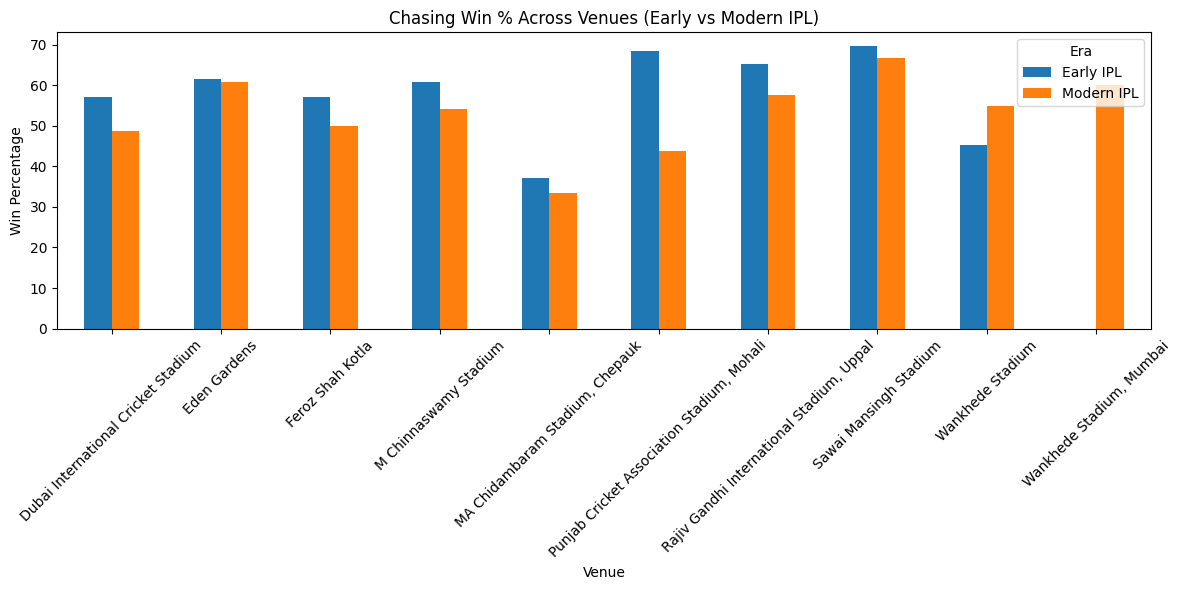

In [13]:
# 9. Visualization (Grouped Bar)

pivot_chase.plot(kind="bar", figsize=(12,6))

plt.title("Chasing Win % Across Venues (Early vs Modern IPL)")
plt.xlabel("Venue")
plt.ylabel("Win Percentage")
plt.xticks(rotation=45)

plt.legend(title="Era")
plt.tight_layout()
plt.show()